In [1]:
%matplotlib inline

In [2]:
from pylab import *

In [3]:
from pySSTri import SSTriggerInterferometer
import time

In [5]:
Trigger = SSTriggerInterferometer()  # COM=None → autodiscover on connect()
Trigger.connect()
#Trigger = SSTriggerInterferometer(COM='COM5')  # connects immediately


PSOC trigger with ID 'PSOC 5LP Trigger; FW:1.3.1; DATE:2026-07-23' found in port COM5


In [6]:
Trigger.discoverMethods()

0 - ID - *IDN? - 
1 - GetFrequency - SIG:TRIG:EVENTS:FREQ? - Hz
2 - GetTriggeredFrames - SIG:TRIG:EVENTS:COUNT? - 
3 - GetSweepTime - LASER:SWE:TIME? - us
4 - GetSweepCount - LASER:SWE:COUNT? - total sweeps since reset
5 - GetSweepStatus - LASER:SWE:STATUS? - 1=sweeping, 0=idle
6 - GetMode - SYS:TRIG:NOT? - {'OFF': 0, 'TIME': 1, 'COUNT': 2, 'FREQ': 3, 'ALL': 4, 'TIMESTAMP': 5}
7 - SetModeNormal - SYS:TRIG:NOT OFF - notify off
8 - SetModeTime - SYS:TRIG:NOT TIME - 
9 - SetModeCount - SYS:TRIG:NOT COUNT - 
10 - SetModeFrequency - SYS:TRIG:NOT FREQ - 
11 - SetModeAll - SYS:TRIG:NOT ALL - 
12 - SetModeTimestamp - SYS:TRIG:NOT TIMESTAMP - unsolicited TSU dump each sweep (us)
13 - GetTimestampsEncoding - SYS:TIMESTAMP:DELTAENC? - OFF or UINT8/16 WARNING…
14 - SetTimestampsEncoding - SYS:TIMESTAMP:DELTAENC <value> - OFF|UINT8|UINT16 or 0|1|2 (aliases in FW)
15 - GetFreqDivision - SIG:TRIG:DIV? - 
16 - SetFreqDivision - SIG:TRIG:DIV <value> - <n>
17 - ResetSweepCount - LASER:SWE:COUNT 0 - rese

In [33]:
Trigger.flushSerialBuffer()

In [34]:
Trigger.ID()

'ERROR: 1'

In [39]:
ts, ov, fc = Trigger.GetTimestamps()

In [38]:
fs = Trigger.GetFrequency()
Ts = Trigger.GetSweepTime()
print(fs, Ts)

2982.723145 339330


In [37]:
print(ts[0] ,ts[-1])

494 1669304


In [12]:
sweeplabel = Trigger.GetSweepCount()

In [13]:
Trigger.SetTimestampsEncoding(0)

'OK'

3005.833252 336728
0 1012


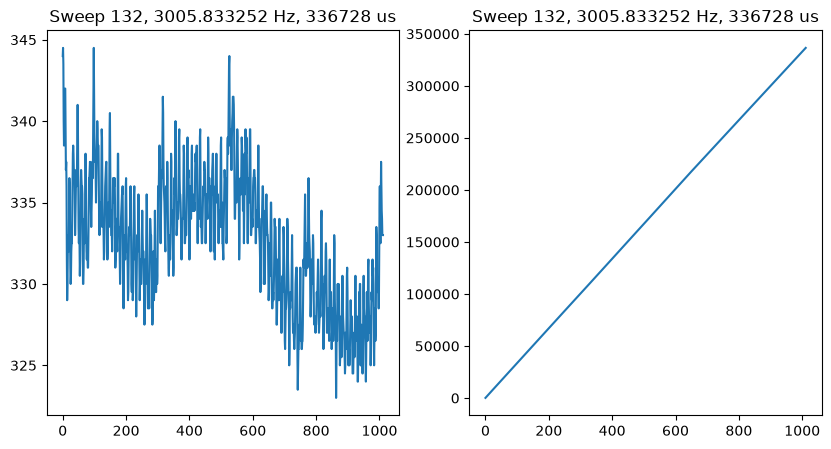

In [43]:
fig, ax = subplots(1,2, figsize=(10,5))
ts, ov, fc = Trigger.GetTimestamps()
sweeplabel = Trigger.GetSweepCount()
fs = Trigger.GetFrequency()
Ts = Trigger.GetSweepTime()
print(fs, Ts)
ax[0].plot(gradient(ts))
ax[1].plot(ts)

ax[0].set_title(f"Sweep {sweeplabel}, {fs} Hz, {Ts} us")
ax[1].set_title(f"Sweep {sweeplabel}, {fs} Hz, {Ts} us")
print(ov, fc)

6030.132812 167837
0 1012


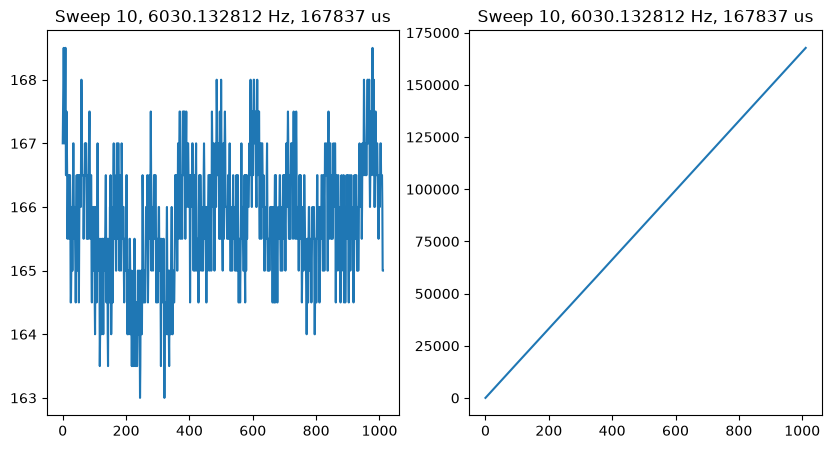

In [32]:
fig, ax = subplots(1,2, figsize=(10,5))
ts, ov, fc = Trigger.GetTimestamps()
sweeplabel = Trigger.GetSweepCount()
fs = Trigger.GetFrequency()
Ts = Trigger.GetSweepTime()
print(fs, Ts)
ax[0].plot(gradient(ts))
ax[1].plot(ts)
ax[0].set_title(f"Sweep {sweeplabel}, {fs} Hz, {Ts} us")
ax[1].set_title(f"Sweep {sweeplabel}, {fs} Hz, {Ts} us")
print(ov, fc)

In [8]:
print(Trigger.ID())  # expect FW:1.2.0; boot banner "Trigger ready ISR"
Trigger.flushSerialBuffer()
ts, ov, fc = Trigger.waitTimestamps(timeout_s=15.0)
print(f"n={len(ts)}  fc={fc}  ov={ov}")
print(ts[:12])
# Good ISR capture: n≈fc and mostly decreasing

PSOC 5LP Trigger; FW:1.2.2; DATE:2026-07-23


RuntimeError: Timeout waiting for TS header (last line='')

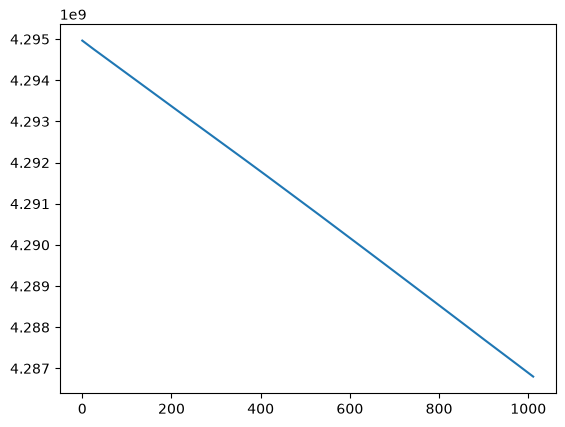

In [9]:
plot(ts)

In [11]:
Trigger.flushSerialBuffer()
Trigger.GetSweepTime()

'340561'

In [12]:
Trigger.flushSerialBuffer()
Trigger.GetFrequency()

'0.000000'

In [42]:
N = Trigger.GetTriggeredFrames()

In [43]:
print(ts.shape, N)

(1013,) 1013


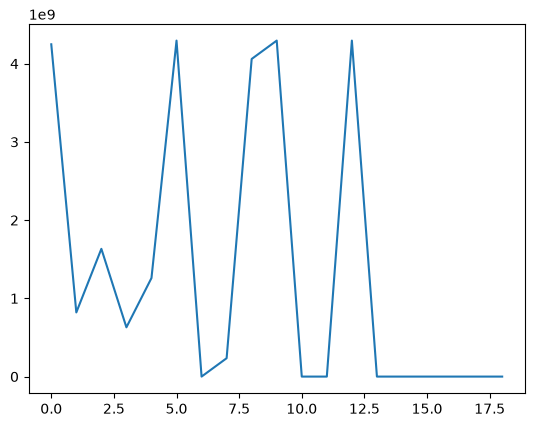

In [44]:
plot(diff(ts[0:20]))

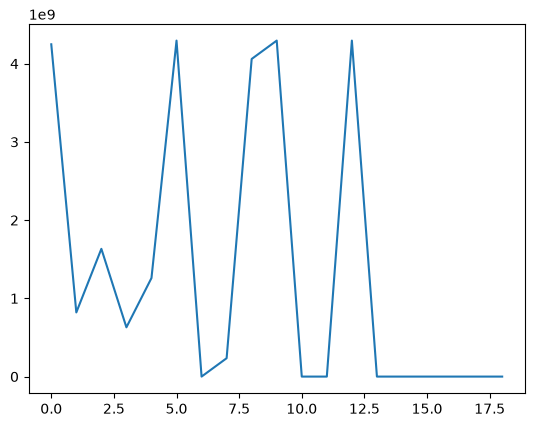

In [36]:
plot(diff(ts[0:20]))

In [23]:
print(ts[:20])


[4294964647 4247584643  772701500 2405667578 3035371575      51941
          0        512  234881024       1792          0          0
        384          0          0          0          0          0
          0       4096]
monotonic? False
n zeros 977
diff raw (should be negative-ish) [  -47380004 -3474883143  1632966078   629703997 -3035319634      -51941
         512   234880512  -234879232       -1792]


In [47]:
Trigger.flushSerialBuffer()
ts1, ov1, fc1 = Trigger.waitTimestamps()
print("First", len(ts1), "fc", fc1, "ov", ov1)
Trigger.flushSerialBuffer()
ts2, ov2, fc2 = Trigger.waitTimestamps()
print("Second", len(ts2), "fc", fc2, "ov", ov2)
print("same?", np.array_equal(ts1, ts2))
print(ts1[:8])
print(ts2[:8])
print("zeros", (ts1 == 0).sum(), (ts2 == 0).sum())

First Trigger Event Acquiered
False [4294966678 4247584643  772701500 2405667578 3035371575      51941
          0        512] [4294966951 4247584643  772701500 2405667578 3035371575      51941
          0        512] 978 978


In [9]:
Trigger.GetFreqDivision()

'2'

In [50]:
ts1[:8], ts2[:8]

(array([4294966678, 4247584643,  772701500, 2405667578, 3035371575,
             51941,          0,        512], dtype=uint32),
 array([4294966951, 4247584643,  772701500, 2405667578, 3035371575,
             51941,          0,        512], dtype=uint32))

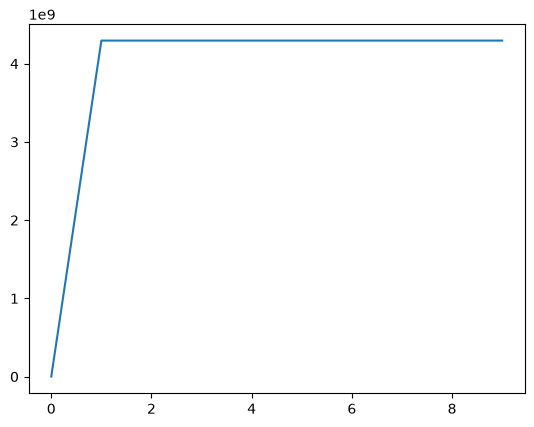

In [54]:
plot(((ts2 - ts2[0]) - (ts1 - ts1[0]))[0:10])

In [8]:
Trigger.flushSerialBuffer()
Trigger.GetSweepTime()

'0'

In [55]:
Trigger.flushSerialBuffer()
Trigger.GetFrequency()

'0.000000'

In [21]:
Trigger.flushSerialBuffer()
Trigger.SetModeAll()

'OK'

In [33]:
Trigger.SetSerialTimeOut(2)

In [10]:
message = Trigger.waitForSignal()

In [11]:
message

'1012 1012 0 4294963275'

In [23]:
for i in range(10):
    message = Trigger.waitForSignal()
    print(message)

0 1012 0.000000
0 1013 0.000000
0 1012 0.000000
0 1012 0.000000
0 1012 0.000000
0 1012 0.000000
0 1012 0.000000
0 1013 0.000000
0 1013 0.000000
0 1013 0.000000


In [17]:
178956970 - 2**32

-4116010326

In [16]:
178956970 

178956970

In [9]:
Trigger.GetFreqDivision()

'1'

In [10]:
Trigger.SetFreqDivision(2)

'OK'

In [34]:
int(Trigger.GetMode())

0

In [17]:
Trigger.flushSerialBuffer()

In [18]:
Trigger.GetFrequency()

UnicodeDecodeError: 'utf-8' codec can't decode byte 0xd0 in position 4: invalid continuation byte

In [19]:
Trigger.GetTriggeredFrames()

UnicodeDecodeError: 'utf-8' codec can't decode byte 0xd7 in position 1: invalid continuation byte

In [12]:
Trigger.GetSweepTime()

'0'

In [14]:
# Raw SCPI also works:
Trigger.scpi('SYS:TRIG:NOT?')

'0'

In [ ]:
Trigger.SetModeNormal()  # SYS:TRIG:NOT OFF

In [11]:
Trigger.flushSerialBuffer()
Trigger.SetModeAll()

'OK'

In [35]:
Trigger.SetModeCount()  # SYS:TRIG:NOT COUNT -> OK
Trigger.flushSerialBuffer()

In [36]:
for i in range(10):
    message = Trigger.waitForSignal()
    print(message)

1012
1012
1012
1012
1012
1012
1012
1012
1012
1012


In [ ]:
Trigger.SetModeNormal()

In [ ]:
Trigger.SetSerialTimeOut(9999)

In [ ]:
Trigger.CloseSerialConnection()